In [109]:
# Erstmal alle notwendigen Pakete importieren. Somit behält man auch die übersicht, wenn später noc welche hinzukommen.
import numpy as np
import matplotlib.pyplot as plt
import uncertainties 
import uncertainties.unumpy as unp
from uncertainties import ufloat
from scipy import optimize as opt
from scipy import odr

In [23]:
# Zuerst wollen wir die Daten einlesen. Dazu nutzen wir die Funktion loadtxt aus dem Paket numpy.
# Da wir mehrere Datenreihen haben, kann man sich hierfür eine Methode schreiben.
def load_data(filename):
    """
    Lädt die Daten aus einer Datei und gibt sie als numpy-Array zurück.
    """
    data = np.loadtxt(filename, delimiter=',', unpack=True, skiprows=1)
    return data
t, ax, ay, az, a = load_data(r"..\Versuch-PYT\Messdaten Federpendel\Smartphone.csv")

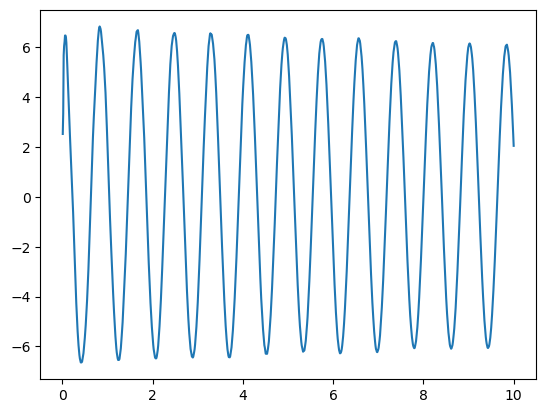

In [24]:
# Austetsten welche Beschleunigung benötigt wird.

#plt.plot(t, ax, label='ax')
plt.plot(t, ay, label='ay')
#plt.plot(t, az, label='az')
#plt.plot(t, a, label='a')

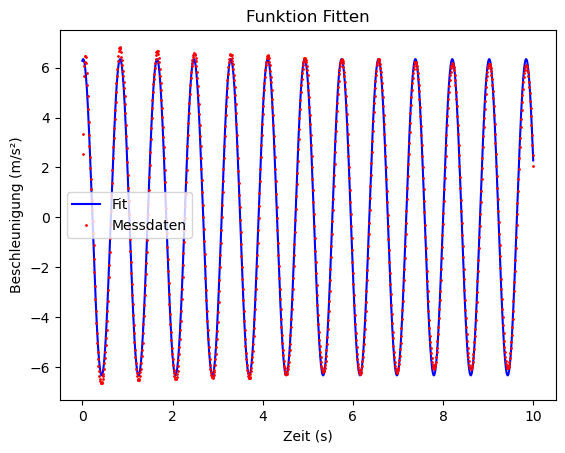

In [ ]:
#Nun wird nach einer passenden Funktion gesucht, die die Daten beschreibt.
#Hierfür wird eine Funktion definiert. Offensichtlcher weise ist es eine Sinusfunktion, die die Beschleunigung in y-Richtung beschreibt.

def f(x, a, o, p):
    y = a*np.sin(o*x+p)
    return y

x = np.linspace(0, 10, 1000)  # Erstellen eines x-Werte Bereichs für die Funktion

para, cov = opt.curve_fit(f, t, ay, bounds=([5, 0, 0], [10, 15, np.pi])) # Berechnen der Parameter

y = f(x, *para)  # Berechnen der y-Werte für die Funktion

plt.plot(x, y, label='Fit', color='blue')  
plt.plot(t, ay, 'o', label='Messdaten', markersize='1', color='red')  # Plotten der Messdaten
plt.xlabel('Zeit (s)')
plt.ylabel('Beschleunigung (m/s²)')
plt.title('Funktion Fitten')
plt.legend()

Das sieht erstmal gut aus, am Anfang ist die gefittete Amplitude zu groß, am Ende zu klein. Das ist auch Richtig so, woran könnte dies liegen?
Wir erhalten nun also unsere Parameter:

In [ ]:
# Nun werden die Parameter zusammen mit ihren Unsicherheiten ausgeben.
U = np.sqrt(np.diag(cov))  # Berechnen der Unsicherheiten
A = ufloat(para[0], U[0])  # Amplitude
O = ufloat(para[1], U[1])  # Frequenz
P = ufloat(para[2], U[2])  # Phase
print(f"Amplitude: {A:.2f} m/s²")
print(f"Winkelfrequenz: {O:.2f} 1/s")
print(f"Phase: {P:.2f} rad")

# Für später speichern wir die Werte schonmal in einem Array ab:
M0 = np.array([A, O, P])

Amplitude: 6.34+/-0.01 m/s²
Winkelfrequenz: 7.67+/-0.00 1/s
Phase: 1.42+/-0.00 rad


Was hier jetzt einmal Ausführlich für eine Messreihe gemacht wurde, folgt nun in schnell, für die weiteren:

In [ ]:
# Den Rest einlesen:
t_1, ax_1, ay_1, az_1, a_1 = load_data(r"..\Versuch-PYT\Messdaten Federpendel\Smartphone_1_Massestueck.csv")
t_2, ax_2, ay_2, az_2, a_2 = load_data(r"..\Versuch-PYT\Messdaten Federpendel\Smartphone_2_Massestuecke.csv")
t_3, ax_3, ay_3, az_3, a_3 = load_data(r"..\Versuch-PYT\Messdaten Federpendel\Smartphone_3_Massestuecke.csv")
t_4, ax_4, ay_4, az_4, a_4 = load_data(r"..\Versuch-PYT\Messdaten Federpendel\Smartphone_4_Massestuecke.csv")
t_5, ax_5, ay_5, az_5, a_5 = load_data(r"..\Versuch-PYT\Messdaten Federpendel\Smartphone_5_Massestuecke.csv")

Text(0.5, 1.0, '5 Massestücke')

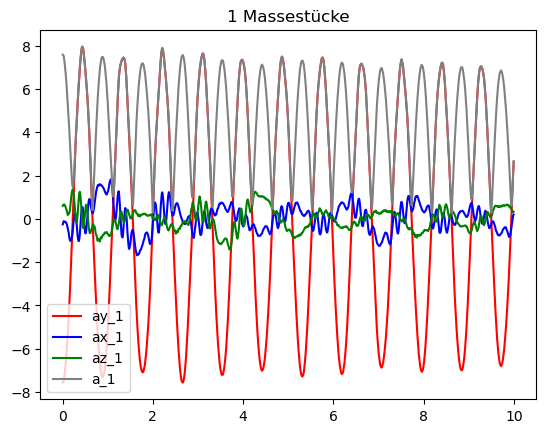

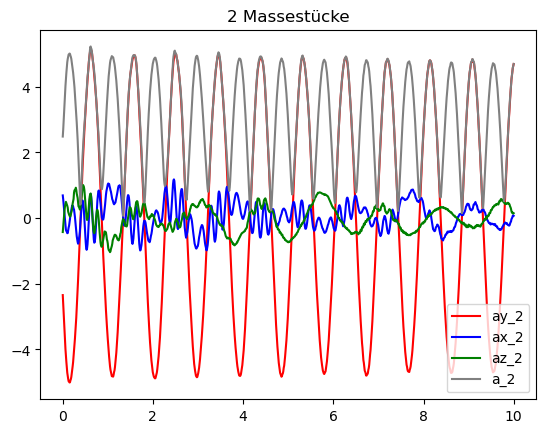

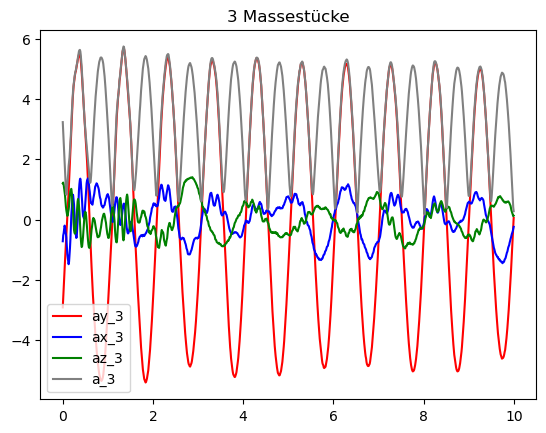

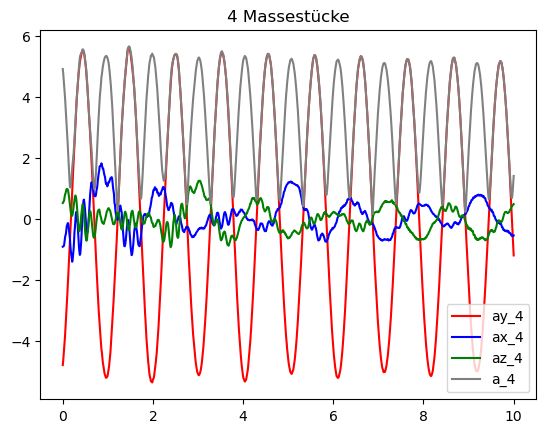

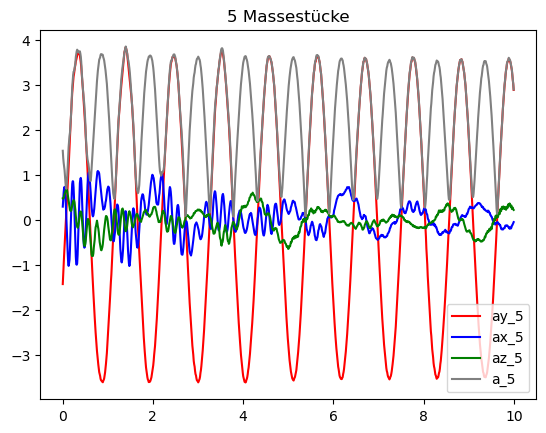

In [36]:
# Richtige Beschleunigung suchen:

# 1 Massestück:
plt.plot(t_1, ay_1, label='ay_1', color='red')
plt.plot(t_1, ax_1, label='ax_1', color='blue')
plt.plot(t_1, az_1, label='az_1', color='green')
plt.plot(t_1, a_1, label='a_1', color='grey')
plt.legend()
plt.title('1 Massestücke')

# 2 Massestücke:
plt.figure()
plt.plot(t_2, ay_2, label='ay_2', color='red')
plt.plot(t_2, ax_2, label='ax_2', color='blue')
plt.plot(t_2, az_2, label='az_2', color='green')
plt.plot(t_2, a_2, label='a_2', color='grey')
plt.legend()
plt.title('2 Massestücke')

# 3 Massestücke:
plt.figure()
plt.plot(t_3, ay_3, label='ay_3', color='red')
plt.plot(t_3, ax_3, label='ax_3', color='blue')
plt.plot(t_3, az_3, label='az_3', color='green')
plt.plot(t_3, a_3, label='a_3', color='grey')
plt.legend()
plt.title('3 Massestücke')

# 4 Massestücke:
plt.figure()
plt.plot(t_4, ay_4, label='ay_4', color='red')
plt.plot(t_4, ax_4, label='ax_4', color='blue')
plt.plot(t_4, az_4, label='az_4', color='green')
plt.plot(t_4, a_4, label='a_4', color='grey')
plt.legend()
plt.title('4 Massestücke')

# 5 Massestücke:
plt.figure()
plt.plot(t_5, ay_5, label='ay_5', color='red')
plt.plot(t_5, ax_5, label='ax_5', color='blue')
plt.plot(t_5, az_5, label='az_5', color='green')
plt.plot(t_5, a_5, label='a_5', color='grey')
plt.legend()
plt.title('5 Massestücke')


Es scheint so, als wäre der rote Graph, somit ay, immer der Richtige.

In [80]:
# Nun wollen wir wieder eine Funktion fitten:
para_1, cov_1 = opt.curve_fit(f, t_1, ay_1, bounds=([4, 0, 0], [10, 15, 2*np.pi]))
y_1 = f(x, *para_1)  
para_2, cov_2 = opt.curve_fit(f, t_2, ay_2, bounds=([5, 4, np.pi], [8, 9, 2*np.pi]))
y_2 = f(x, *para_2)  
para_3, cov_3 = opt.curve_fit(f, t_3, ay_3, bounds=([5, 4, np.pi], [8, 9, 2*np.pi]))
y_3 = f(x, *para_3)  
para_4, cov_4 = opt.curve_fit(f, t_4, ay_4, bounds=([5, 4, np.pi], [8, 8, 2*np.pi]))
y_4 = f(x, *para_4)  
para_5, cov_5 = opt.curve_fit(f, t_5, ay_5, bounds=([3, 4, np.pi], [6, 8, 2*np.pi]))
y_5 = f(x, *para_5)  

Text(0.5, 1.0, 'Fit 5')

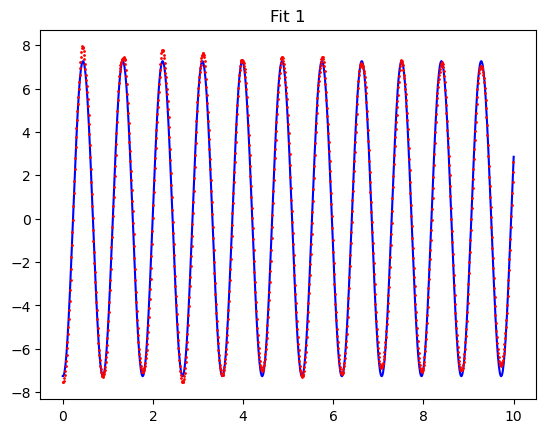

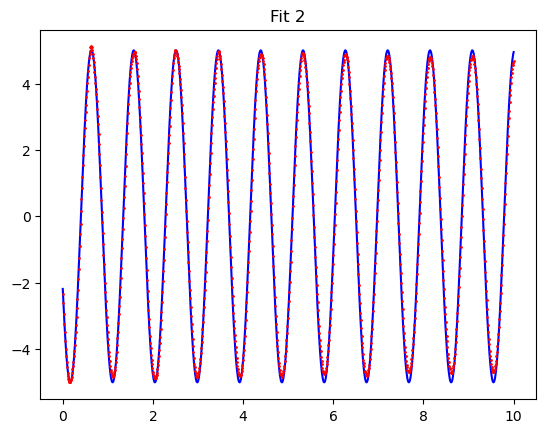

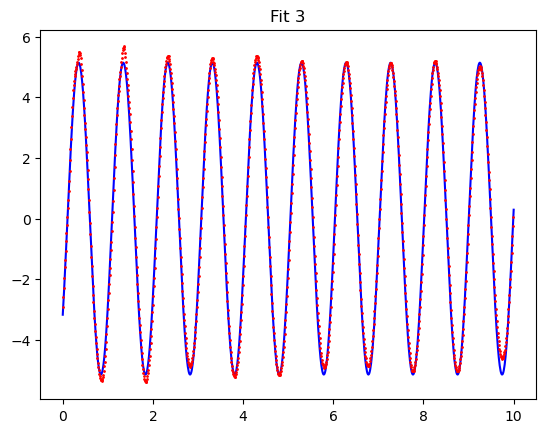

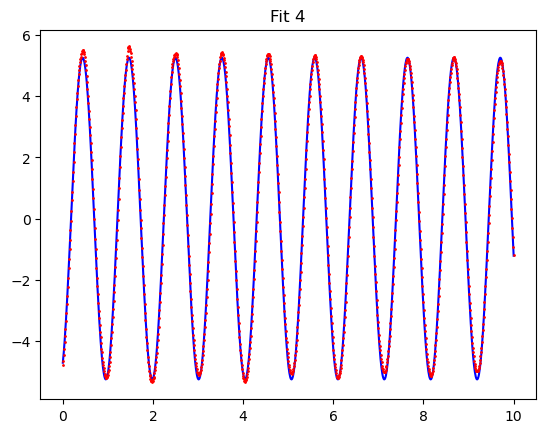

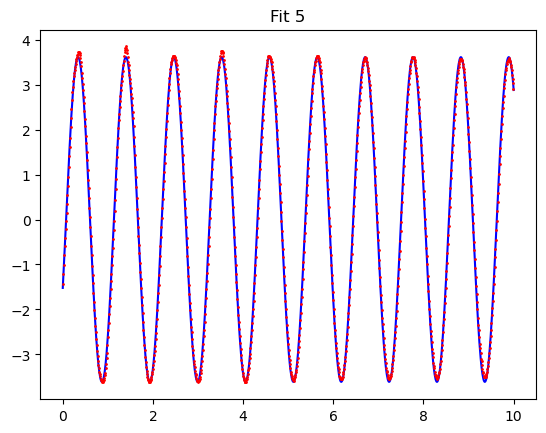

In [81]:
# Testen, wie gut die Fits sind, ansonsten die Parameter anpassen.
# (Hier wurden die Parameter schon entsprechen angepasst):
plt.plot(x, y_1, label='Fit 1', color='blue')  
plt.plot(t_1, ay_1, 'o', label='Messdaten 1', markersize='1', color='red')
plt.title('Fit 1')

plt.figure()
plt.plot(x, y_2, label='Fit 2', color='blue')  
plt.plot(t_2, ay_2, 'o', label='Messdaten 2', markersize='1', color='red')
plt.title('Fit 2')

plt.figure()
plt.plot(x, y_3, label='Fit 3', color='blue')  
plt.plot(t_3, ay_3, 'o', label='Messdaten 3', markersize='1', color='red')
plt.title('Fit 3')

plt.figure()
plt.plot(x, y_4, label='Fit 4', color='blue')  
plt.plot(t_4, ay_4, 'o', label='Messdaten 4', markersize='1', color='red')
plt.title('Fit 4')

plt.figure()
plt.plot(x, y_5, label='Fit 5', color='blue')  
plt.plot(t_5, ay_5, 'o', label='Messdaten 5', markersize='1', color='red')
plt.title('Fit 5')

In [101]:
# Parameter mit Unsicherheiten berechnen:
U1 = np.sqrt(np.diag(cov_1))
U2 = np.sqrt(np.diag(cov_2))
U3 = np.sqrt(np.diag(cov_3))
U4 = np.sqrt(np.diag(cov_4))
U5 = np.sqrt(np.diag(cov_5))
M1 = np.array([ufloat(para_1[0], U1[0]), ufloat(para_1[1], U1[1]), ufloat(para_1[2], U1[2])])  # 1 Massestück
M2 = np.array([ufloat(para_2[0], U2[0]), ufloat(para_2[1], U2[1]), ufloat(para_2[2], U2[2])])  # 2 Massestücke
M3 = np.array([ufloat(para_3[0], U3[0]), ufloat(para_3[1], U3[1]), ufloat(para_3[2], U3[2])])  # 3 Massestücke
M4 = np.array([ufloat(para_4[0], U4[0]), ufloat(para_4[1], U4[1]), ufloat(para_4[2], U4[2])])  # 4 Massestücke
M5 = np.array([ufloat(para_5[0], U5[0]), ufloat(para_5[1], U5[1]), ufloat(para_5[2], U5[2])])  # 5 Massestücke
print(f"1 Massestück: {M1[0]:.2f}, {M1[1]:.2f}, {M1[2]:.2f}")
print(f"2 Massestücke: {M2[0]:.2f}, {M2[1]:.2f}, {M2[2]:.2f}")
print(f"3 Massestücke: {M3[0]:.2f}, {M3[1]:.2f}, {M3[2]:.2f}")
print(f"4 Massestücke: {M4[0]:.2f}, {M4[1]:.2f}, {M4[2]:.2f}")
print(f"5 Massestücke: {M5[0]:.2f}, {M5[1]:.2f}, {M5[2]:.2f}")

# Nun speichern wir unsere Winkelfrequenzen:
w = unp.uarray([para[1], para_1[1], para_2[1], para_3[1], para_4[1], para_5[1]], [U[1], U1[1], U2[1], U3[1], U4[1], U5[1]])
print(f"Winkelfrequenzen: {w}")

1 Massestück: 7.27+/-0.01, 7.11+/-0.00, 4.67+/-0.00
2 Massestücke: 5.00+/-0.01, 6.69+/-0.00, 3.59+/-0.00
3 Massestücke: 5.14+/-0.01, 6.36+/-0.00, 5.62+/-0.00
4 Massestücke: 5.26+/-0.00, 6.10+/-0.00, 5.17+/-0.00
5 Massestücke: 3.61+/-0.00, 5.92+/-0.00, 5.85+/-0.00
Winkelfrequenzen: [7.674978885009483+/-0.0005442321721209427
 7.113232487173675+/-0.0004238487641825333
 6.69474915819629+/-0.0004389882456305169
 6.355294491503195+/-0.0005081705870022836
 6.10345008713616+/-0.00031836141272633854
 5.920198751629147+/-0.00023381573863030482]


Nun brauchen wir noch die Massen inklusive Unsicherheiten

In [97]:
Ms = ufloat(0.1829, 0.001) # Masse des Smartphones in kg
Mg = ufloat(0.026, 0.006) # Masse eines Massestücks in kg	
M0 = Ms
M1 = Ms + Mg
M2 = Ms + 2*Mg
M3 = Ms + 3*Mg
M4 = Ms + 4*Mg
M5 = Ms + 5*Mg
m = unp.uarray(
    [unp.nominal_values(M0), unp.nominal_values(M1), unp.nominal_values(M2), unp.nominal_values(M3), unp.nominal_values(M4), unp.nominal_values(M5)],
    [unp.std_devs(M0), unp.std_devs(M1), unp.std_devs(M2), unp.std_devs(M3), unp.std_devs(M4), unp.std_devs(M5)]
)
print(m)

[0.1829+/-0.001 0.2089+/-0.00608276253029822 0.2349+/-0.012041594578792296
 0.2609+/-0.01802775637731995 0.2869+/-0.024020824298928628
 0.3129+/-0.03001666203960727]


[0.00835394 0.00602987 0.00587783 0.00645915 0.00388621 0.00276847]


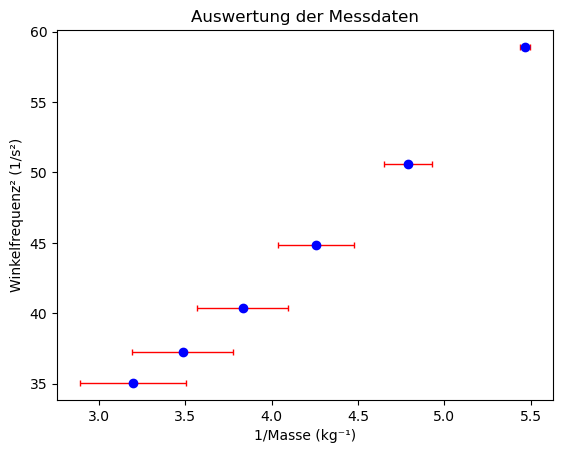

In [108]:
# Nun wird linearisiert:
xl = 1/m
yl = w**2
xl_best = unp.nominal_values(xl)
xl_err = unp.std_devs(xl)
yl_best = unp.nominal_values(yl)
yl_err = unp.std_devs(yl)

# NUn wird geplottet:
plt.errorbar(xl_best, yl_best, xerr=xl_err, yerr=yl_err, fmt='o', color='blue', ecolor='red', elinewidth=1, capsize=2)
plt.xlabel('1/Masse (kg⁻¹)')
plt.ylabel('Winkelfrequenz² (1/s²)')
plt.title('Auswertung der Messdaten')
print(yl_err)

In [117]:
# Nun wollen wir wieder eine Funktion fitten, die die Daten beschreibt.
# Da wir nun Fehler auf die x-Werte haben, nutzen wir die ODR-Methode (Orthogonal Distance Regression) aus dem Paket scipy.
def g(B, x):
    return B[0] * x + B[1]
# Definieren der ODR-Modelle
model = odr.Model(g)
# Definieren der ODR-Daten
data = odr.Data(xl_best, yl_best, wd=yl_err, we=xl_err)
# Definieren der ODR-Objekte
odr_obj = odr.ODR(data, model, beta0=[10, 0])  # Vorüberlegung zu den Parametern
# Durchführen der ODR-Analyse
odr_res = odr_obj.run()
# Extrahieren der Parameter und ihrer Unsicherheiten
B = odr_res.beta  # Parameter
U_B = odr_res.sd_beta  # Unsicherheiten der Parameter
# Ausgabe der Parameter
print(f"Steigung: {B[0]:.2f} ± {U_B[0]:.2f} kg/s²")
print(f"Y-Achsenabschnitt: {B[1]:.2f} ± {U_B[1]:.2f} 1/s²")

Steigung: 10.86 ± 0.35 kg/s²
Y-Achsenabschnitt: -0.91 ± 1.58 1/s²


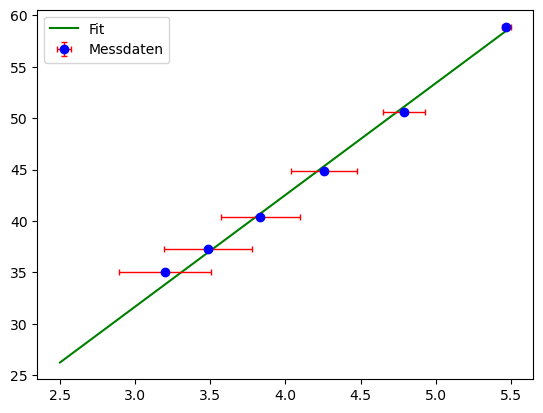

In [114]:
# Nun plotten wir die Fit-Funktion:
z = np.linspace(2.5, 5.5, 1000)  # Erstellen eines x-Werte Bereichs für die Funktion
plt.plot(z, g(B, z), label='Fit', color='green')  # Plotten der Fit-Funktion
plt.errorbar(xl_best, yl_best, xerr=xl_err, yerr=yl_err, fmt='o', color='blue', ecolor='red', elinewidth=1, capsize=2, label='Messdaten')  # Plotten der Messdaten
plt.legend()

In [120]:
# Hier gibt es nur eine fit Funktion, da direkt ODR verwendet wurde. 
print(f"D = {ufloat(B[0], U_B[0]):.2f} N/m")

D = 10.86+/-0.35 N/m
